# 5. Densité d'états de phonons 

#### Imports et récupération de la structure

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter
from pymatgen.phonon.plotter import PhononDosPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B

API_KEY = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
MP_ID = "mp-1008556"  

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MP_ID)
    phonon_bs = mpr.get_phonon_bandstructure_by_material_id(MP_ID)
    ph_dens = mpr.get_phonon_dos_by_material_id(MP_ID)

## 5.1 Densité d'états de phonons du matériau

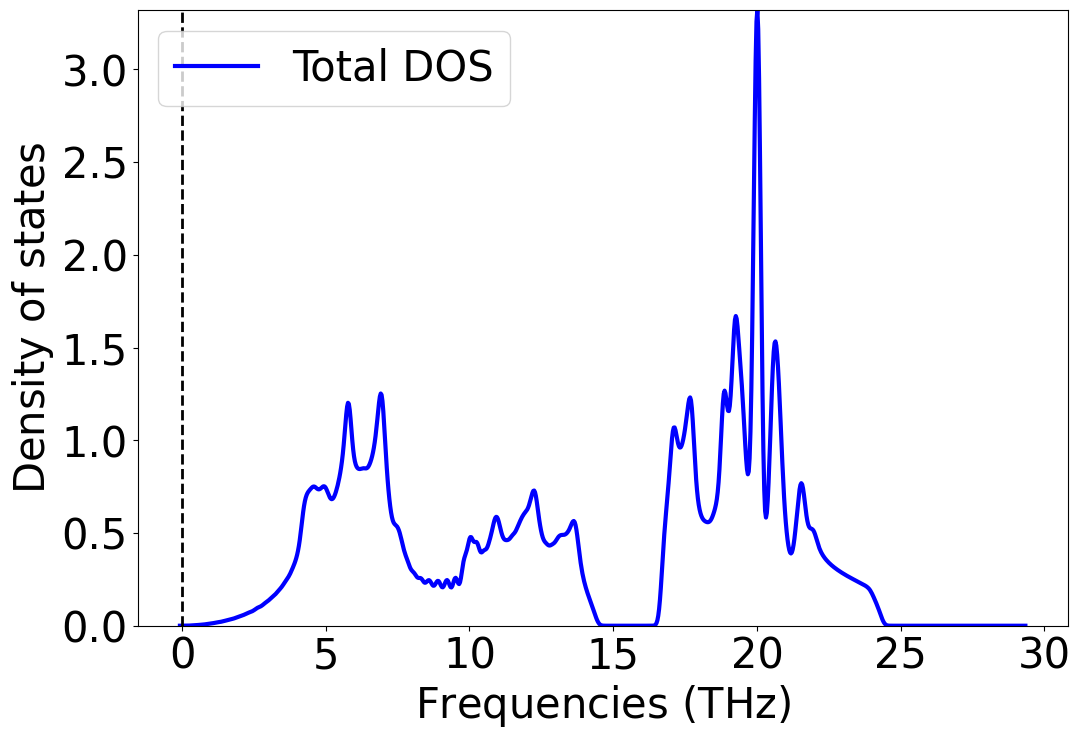

In [2]:
plotter = PhononDosPlotter()
plotter.add_dos("Total DOS", ph_dens)

fig_ph_dens = plotter.get_plot()
plt.show()

## 5.2 Calcul des températures de Debye $\Theta_D$ et d'Einstein $\Theta_E$

Nous cherchons ici à modéliser l'évolution de la chaleur spécifique à volume constant ($C_v$) en fonction de la température à l'aide de deux modèles classiques : le modèle d'Einstein et le modèle de Debye. 

Afin de pouvoir comparer ces modèles à notre matériau, nous normalisons la chaleur spécifique obtenue numériquement par $3N_{at}R$ (où $N_{at}$ est le nombre d'atomes dans la maille et $R$ la constante des gaz parfaits). Nous avons donc une courbe, qui, à haute température, tend asymptotiquement vers $1$, respectant la loi de Dulong-Petit.

**Modèle d'Einstein :**
Ce modèle pose l'hypothèse que tous les atomes du cristal vibrent de manière indépendante à une seule et unique fréquence $\omega_E$. La chaleur spécifique normalisée s'écrit alors :

$$\frac{C_v^{Einstein}}{3N_{at}R} = \left(\frac{\Theta_E}{T}\right)^2 \frac{e^{\Theta_E/T}}{(e^{\Theta_E/T}-1)^2}$$

**Modèle de Debye :**
Le modèle de Debye améliore cette approche en considérant le cristal comme un milieu continu dans lequel les ondes sonores se propagent avec une relation de dispersion linéaire, jusqu'à une fréquence de coupure $\omega_D$ (fréquence de Debye). La chaleur spécifique normalisée devient :

$$\frac{C_v^{Debye}}{3N_{at}R} = 3 \left(\frac{T}{\Theta_D}\right)^3 \int_0^{\Theta_D/T} \frac{x^4 e^x}{(e^x-1)^2} dx$$

Pour déterminer les températures $\Theta_E$ et $\Theta_D$ propres à notre composé, nous allons tester numériquement les températures de 1 K à 1000 K et conserver celles qui minimisent l'erreur au sens des moindres carrés par rapport aux données de Materials Project.

In [5]:
# --- Préparation des données expérimentales ---
# On commence à 5K pour éviter l'erreur de division par zéro dans les modèles
temperatures = np.arange(5, 1005, 5) 
R = 8.314 
Nat = len(structure) 

# Récupération et normalisation de la chaleur spécifique
ph_cv = np.array([ph_dens.cv(T) for T in temperatures]) / (3 * Nat * R)

# --- Recherche de la température d'Einstein ---
def cv_einstein(theta_E, T):
    x = theta_E / T
    return (x**2 * np.exp(x)) / ((np.exp(x) - 1)**2)

err_e_min = float('inf') 
temp_e = 0

for theta in range(1, 1000): 
    erreur_totale = 0
    for i in range(len(temperatures)): 
        cv_pred = cv_einstein(theta, temperatures[i])
        erreur_totale += (cv_pred - ph_cv[i])**2
        
    if erreur_totale < err_e_min: 
        temp_e = theta
        err_e_min = erreur_totale

print(f"Température d'Einstein minimisant l'erreur : {temp_e} K")

# --- Recherche de la température de Debye ---
def integrand_debye(x):
    return (x**4 * np.exp(x)) / ((np.exp(x) - 1)**2)

def cv_debye(theta_D, T):
    integral, _ = integrate.quad(integrand_debye, 0, theta_D / T)
    return 3 * (T / theta_D)**3 * integral

err_d_min = float('inf')
temp_d = 0

for theta in range(1, 1000):
    erreur_totale = 0
    for i in range(len(temperatures)):
        cv_pred = cv_debye(theta, temperatures[i])
        erreur_totale += (cv_pred - ph_cv[i])**2
        
    if erreur_totale < err_d_min:
        temp_d = theta
        err_d_min = erreur_totale

print(f"Température de Debye minimisant l'erreur : {temp_d} K")

Température d'Einstein minimisant l'erreur : 640 K
Température de Debye minimisant l'erreur : 866 K


## 5.3 Représenter les trois courbes de chaleur spécifique (celle correspondant à l'objet téléchargé ainsi que celles obtenues à partir des modèles de Debye et d'Einstein);

## 5.4 Représenter les trois densités d'états de phonons correspondantes.